El código para graficar la eof y calcularla lo obtuve de un ejemplo de la página web de la librería que use para calcular la eof: https://ajdawson.github.io/eofs/examples/nao_xarray.html

In [1]:
import numpy as np
import pandas as pd

import xarray as xr
from eofs.xarray import Eof

import cartopy.crs as ccrs
import matplotlib.pyplot as plt

import os  # Para recorrer directorios

from PIL import Image # Para recortar las gráficas y eliminar el exceso de fondo blanco

Creo un nuevo mapa de color para que los datos cercanos a 0 sean completamente blancos

In [2]:
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

bwr = mpl.colormaps['bwr'].resampled(40)
newcolors = bwr(np.linspace(0, 1, 40))
white = np.array([256/256, 256/256, 256/256, 1])
newcolors[17:23, :] = white
newcmp = ListedColormap(newcolors)

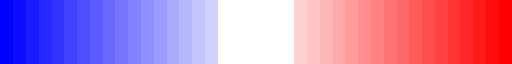

In [24]:
newcmp

In [31]:
eof

<xarray.DataArray 'eofs' (mode: 1, level: 1, lat: 29, lon: 144)> Size: 33kB
array([[[[        nan,         nan,         nan, ...,         nan,
                  nan,         nan],
         [ 0.87821545,  0.87634542,  0.87444563, ...,  0.88283263,
           0.88139003,  0.87994103],
         [ 0.91802638,  0.91400556,  0.90958666, ...,  0.92757056,
           0.92481011,  0.92165   ],
         ...,
         [-0.27468597, -0.25931838, -0.27170156, ..., -0.3212687 ,
          -0.31389708, -0.29738016],
         [-0.21764526, -0.21971739, -0.24375651, ..., -0.24938778,
          -0.24260291, -0.23015374],
         [-0.21366391, -0.23027649, -0.25804027, ..., -0.21220455,
          -0.21113519, -0.20869352]]]], shape=(1, 1, 29, 144))
Coordinates:
  * mode     (mode) int64 8B 0
  * level    (level) float32 4B 850.0
  * lat      (lat) float32 116B 90.0 87.5 85.0 82.5 80.0 ... 27.5 25.0 22.5 20.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
Attributes:
    long_name:  correlation_between_pcs_and_None

# Slice the data depending of the months

In [4]:
def Slice_netcdf(file, months): # hemisph(0=north, 1=south)
    
    ds = xr.open_dataset(file)

    
    hgt = ds['hgt'].values
    time = ds['time'].values
    lon = ds['lon'].values
    lat = ds['lat'].values
    level = ds['level'].values

    years = int(len(time)/12)

    hgt = hgt.reshape((years, 12, 1, 29, 144))

    time = time.reshape((years,12))

    hgt_season = hgt[:, months, :, :, :]  # (años, meses, level, lat, lon)
    time = time[:, months]

    hgt_season = hgt_season.reshape((years * len(months), 1, 29, 144))

    time = time.reshape(years  * len(months))

    HGT = xr.DataArray(
        data=hgt_season,
        dims=["time", 'level', "lat", "lon"],
        coords=dict(
            time=time,
            lon=lon,
            lat=lat,
            level=level))

    return HGT

# Calculate the EOF

In [26]:
def Calc_eof(HGT):
    #HGT = HGT - HGT.mean(dim='time')

    # Create an EOF solver to do the EOF analysis. Square-root of cosine of
    # latitude weights are applied before the computation of EOFs.
    coslat = np.cos(np.deg2rad(HGT.coords['lat'].values)).clip(0., 1.)
    wgts = np.sqrt(coslat)[..., np.newaxis]
    solver = Eof(HGT, weights=wgts)
    
    # Retrieve the leading EOF, expressed as the covariance between the leading PC
    # time series and the input SLP anomalies at each grid point.
    eof = solver.eofsAsCorrelation(neofs=1)

    return eof

# Slice data for Alta-Baja

In [27]:
def Slice_flux(data, months):

    date = data['Date'].values
    flux = data['flux'].values

    years = int(len(date)/12)

    date = date.reshape((years, 12))

    flux = flux.reshape((years,12))

    date_sliced = date[:, months]  # (años, meses)
    flux = flux[:, months]

    date_sliced = date_sliced.reshape((years * len(months)))
    flux = flux.reshape(years  * len(months))

    flux_sliced = xr.DataArray(
        data=flux,
        dims=["Date"],
        coords=dict(
            Date=date_sliced))

    return flux_sliced

# Plot EOF

In [34]:
def Graph_eof(eof, folder, file, months, bias):
    ################################# Periodic Conditions: ###################################
    lat = eof["lat"].values
    lon = eof["lon"].values
    eof_aux = eof.values[0][0]
    
    eof_dat = np.zeros([29,145])
    eof_dat[:,:144] = eof_aux
    eof_dat[:,144] = eof_aux[:,0]
    
    lon = np.append(lon, 360)

    eof = xr.DataArray(
                        data=eof_dat,
                        dims=["lat", "lon"],
                        coords=dict(lon=lon, lat=lat))
    
    ############################ Plot the EOF expressed as correlation ########################## 
    clevs = np.linspace(-1, 1, 41)
    
    if ("N" in file):
        proj = ccrs.Orthographic(central_longitude=0, central_latitude=90)    

    elif ("S" in file):
        proj = ccrs.Orthographic(central_longitude=0, central_latitude=-90)
        
    ax = plt.axes(projection=proj)
    ax.coastlines()
    ax.set_global()
    
    eof.plot.contourf(ax=ax, levels=clevs, cmap=newcmp,
                             transform=ccrs.PlateCarree(), add_colorbar=True)

    #plt.savefig(f"{folder}/{file}/{bias}-{months}.png")

# Main

# Slice the Flux

In [35]:
flux_data = pd.read_csv("Sun_Data.csv")
flux_data.drop(['ssn', 'swpc_ssn'], axis=1, inplace=True)
flux_data = flux_data[(flux_data["Date"] >= "1948") & (flux_data["Date"] < "2025")].reset_index().to_xarray()

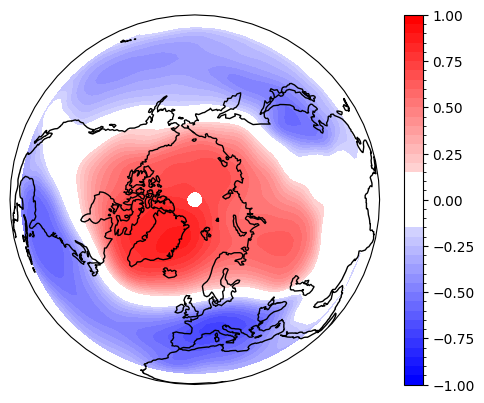

In [41]:
HGT = Slice_netcdf(f"AMZ/NAMZ850.nc", [0])
#flux = Slice_flux(flux_data, [5,6,7])
#alta = flux[(flux - flux.mean()) / flux.std() <= -1]["Date"].values
#HGT_baja = HGT.where(HGT["time"].isin(pd.to_datetime(alta, format="%Y-%m")), drop=True)

eof = Calc_eof(HGT)

## Plot:
Graph_eof(eof, "Plots", "NAMZ500", "jun-ago", "Baja")

## Meses de interés por hemisferio

In [42]:
folder = "Plots"

In [43]:
p_months_north = {"ene-mar":[0,1,2], "jun-ago":[5,6,7]}
p_months_south = {"nov":[10], "jun-ago":[5,6,7], "feb-mar":[1,2]}

### Normal

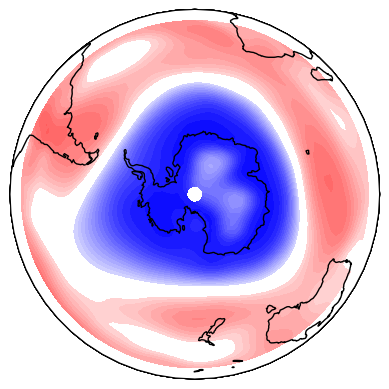

In [13]:
directory = os.scandir("./AMZ")

for amz in directory:
    
    if ("N" in amz.name):
        
        for months in p_months_north.keys():
    
            ## Calculate the EOF: 
            HGT = Slice_netcdf(f"AMZ/{amz.name}", p_months_north[months])
            eof = Calc_eof(HGT)
            
            ## Plot:
            Graph_eof(eof, folder, amz.name[:-3], months, "Normal")

directory = os.scandir("./AMZ")
for amz in directory:

    if("S" in amz.name):
        
        for months in p_months_south.keys():
            
            ## Calculate the EOF: 
            HGT = Slice_netcdf(f"AMZ/{amz.name}", p_months_south[months])
            eof = Calc_eof(HGT)
            
            ## Plot:
            Graph_eof(eof, folder, amz.name[:-3], months, "Normal")

### Alta

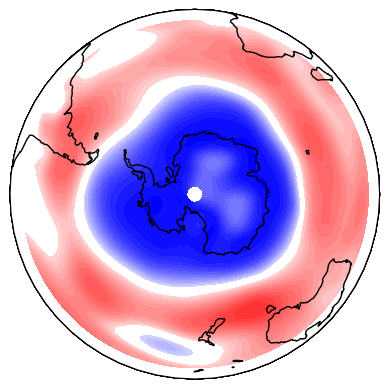

In [28]:
directory = os.scandir("./AMZ")

for amz in directory:
    
    if ("N" in amz.name):
        
        for months in p_months_north.keys():
    
            ## Calculate the EOF: 
            HGT = Slice_netcdf(f"AMZ/{amz.name}", p_months_north[months])   # North
            
            flux = Slice_flux(flux_data, p_months_north[months])
            alta = flux[(flux - flux.mean()) / flux.std() >= 1]["Date"].values
            HGT_alta = HGT.where(HGT["time"].isin(pd.to_datetime(alta, format="%Y-%m")), drop=True)
            
            eof = Calc_eof(HGT_alta)
            
            ## Plot:
            Graph_eof(eof, folder, amz.name[:-3], months, "Alta")

directory = os.scandir("./AMZ")
for amz in directory:

    if("S" in amz.name):
        
        for months in p_months_south.keys():
            
            ## Calculate the EOF: 
            HGT = Slice_netcdf(f"AMZ/{amz.name}", p_months_south[months])   # South

            flux = Slice_flux(flux_data, p_months_south[months])
            alta = flux[(flux - flux.mean()) / flux.std() >= 1]["Date"].values
            HGT_alta = HGT.where(HGT["time"].isin(pd.to_datetime(alta, format="%Y-%m")), drop=True)
            
            eof = Calc_eof(HGT_alta)
            
            ## Plot:
            Graph_eof(eof, folder, amz.name[:-3], months, "Alta")

### Baja

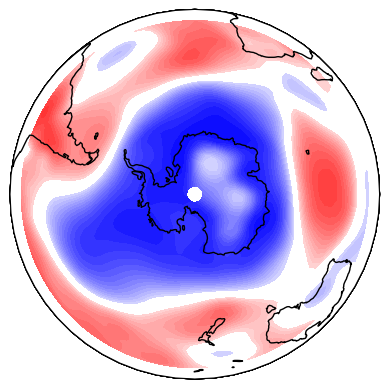

In [29]:
directory = os.scandir("./AMZ")

for amz in directory:
    
    if ("N" in amz.name):
        
        for months in p_months_north.keys():
    
            ## Calculate the EOF: 
            HGT = Slice_netcdf(f"AMZ/{amz.name}", p_months_north[months])   # North
            
            flux = Slice_flux(flux_data, p_months_north[months])
            alta = flux[(flux - flux.mean()) / flux.std() <= -1]["Date"].values
            HGT_baja = HGT.where(HGT["time"].isin(pd.to_datetime(alta, format="%Y-%m")), drop=True)
            
            eof = Calc_eof(HGT_baja)
            
            ## Plot:
            Graph_eof(eof, folder, amz.name[:-3], months, "Baja")

directory = os.scandir("./AMZ")
for amz in directory:

    if("S" in amz.name):
        
        for months in p_months_south.keys():
            
            ## Calculate the EOF: 
            HGT = Slice_netcdf(f"AMZ/{amz.name}", p_months_south[months])   # South

            flux = Slice_flux(flux_data, p_months_south[months])
            alta = flux[(flux - flux.mean()) / flux.std() <= -1]["Date"].values
            HGT_baja = HGT.where(HGT["time"].isin(pd.to_datetime(alta, format="%Y-%m")), drop=True)
            
            eof = Calc_eof(HGT_baja)
            
            ## Plot:
            Graph_eof(eof, folder, amz.name[:-3], months, "Baja")

# Create Colorbar

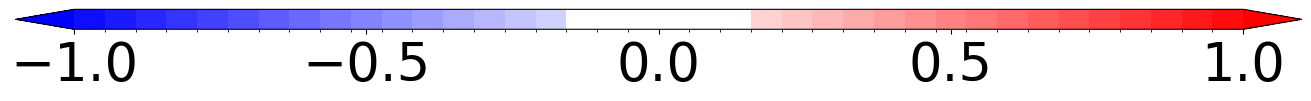

In [38]:
fig, ax = plt.subplots(figsize=(13, 0.9), layout='constrained')

bounds = np.linspace(-1,1, 39)
norm = mpl.colors.BoundaryNorm(bounds, newcmp.N, extend='both')

cbar = fig.colorbar(mpl.cm.ScalarMappable(norm, cmap=newcmp),
             cax=ax, orientation='horizontal')
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
cbar.ax.tick_params(labelsize=38)
plt.savefig(f"Plots/colorbar_Sur.png")

# Graficas Mes a Mes

In [58]:
folder = "Plots/Per_Month"

In [61]:
a = [[2],[0]]
a[1][0]

0

In [17]:
p_months_north = {"ene":[[0], [0]], "feb":[[1], [0]], "mar":[[2],[0]], "abr":[[0], [0]], "may":[[0], [1]], "jun":[[0], [1]], "jul":[[0], [1]], "ago":[[0], [1]], "sep":[8], "oct":[9], "noc":[10], "dic":[11]}
p_months_south = {"ene":[0], "feb":[1], "mar":[2], "abr":[3], "may":[4], "jun":[5], "jul":[6], "ago":[7], "sep":[8], "oct":[9], "noc":[10], "dic":[11]}

### Normal

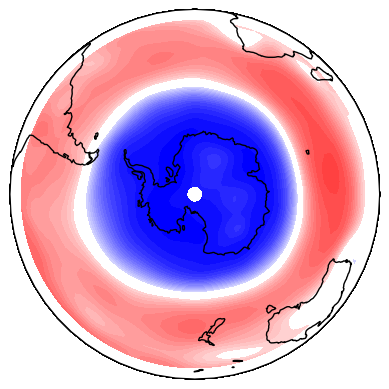

In [18]:
directory = os.scandir("./AMZ")

for amz in directory:
    
    if ("N" in amz.name):
        
        for months in p_months_north.keys():
    
            ## Calculate the EOF: 
            HGT = Slice_netcdf(f"AMZ/{amz.name}", p_months_north[months])
            eof = Calc_eof(HGT)
            
            ## Plot:
            Graph_eof(eof, folder, amz.name[:-3], months, "Normal")

directory = os.scandir("./AMZ")
for amz in directory:

    if("S" in amz.name):
        
        for months in p_months_south.keys():
            
            ## Calculate the EOF: 
            HGT = Slice_netcdf(f"AMZ/{amz.name}", p_months_south[months])
            eof = Calc_eof(HGT)
            
            ## Plot:
            Graph_eof(eof, folder, amz.name[:-3], months, "Normal")

### Alta

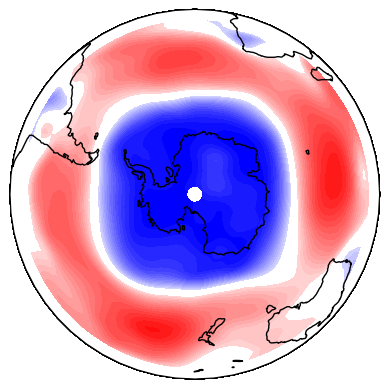

In [19]:
directory = os.scandir("./AMZ")

for amz in directory:
    
    if ("N" in amz.name):
        
        for months in p_months_north.keys():
    
            ## Calculate the EOF: 
            HGT = Slice_netcdf(f"AMZ/{amz.name}", p_months_north[months])   # North
            
            flux = Slice_flux(flux_data, p_months_north[months])
            alta = flux[(flux - flux.mean()) / flux.std() >= 1]["Date"].values
            HGT_alta = HGT.where(HGT["time"].isin(pd.to_datetime(alta, format="%Y-%m")), drop=True)
            
            eof = Calc_eof(HGT_alta)
            
            ## Plot:
            Graph_eof(eof, folder, amz.name[:-3], months, "Alta")

directory = os.scandir("./AMZ")
for amz in directory:

    if("S" in amz.name):
        
        for months in p_months_south.keys():
            
            ## Calculate the EOF: 
            HGT = Slice_netcdf(f"AMZ/{amz.name}", p_months_south[months])   # South

            flux = Slice_flux(flux_data, p_months_south[months])
            alta = flux[(flux - flux.mean()) / flux.std() >= 1]["Date"].values
            HGT_alta = HGT.where(HGT["time"].isin(pd.to_datetime(alta, format="%Y-%m")), drop=True)
            
            eof = Calc_eof(HGT_alta)
            
            ## Plot:
            Graph_eof(eof, folder, amz.name[:-3], months, "Alta")

### Baja

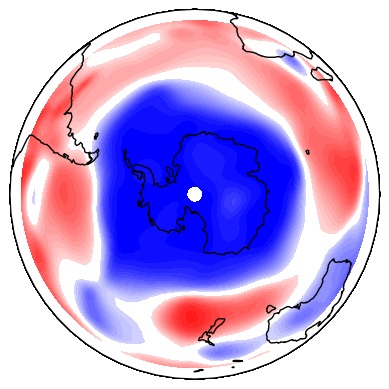

In [20]:
directory = os.scandir("./AMZ")

for amz in directory:
    
    if ("N" in amz.name):
        
        for months in p_months_north.keys():
    
            ## Calculate the EOF: 
            HGT = Slice_netcdf(f"AMZ/{amz.name}", p_months_north[months])   # North
            
            flux = Slice_flux(flux_data, p_months_north[months])
            alta = flux[(flux - flux.mean()) / flux.std() <= -1]["Date"].values
            HGT_baja = HGT.where(HGT["time"].isin(pd.to_datetime(alta, format="%Y-%m")), drop=True)
            
            eof = Calc_eof(HGT_baja)
            
            ## Plot:
            Graph_eof(eof, folder, amz.name[:-3], months, "Baja")

directory = os.scandir("./AMZ")
for amz in directory:

    if("S" in amz.name):
        
        for months in p_months_south.keys():
            
            ## Calculate the EOF: 
            HGT = Slice_netcdf(f"AMZ/{amz.name}", p_months_south[months])   # South

            flux = Slice_flux(flux_data, p_months_south[months])
            alta = flux[(flux - flux.mean()) / flux.std() <= -1]["Date"].values
            HGT_baja = HGT.where(HGT["time"].isin(pd.to_datetime(alta, format="%Y-%m")), drop=True)
            
            eof = Calc_eof(HGT_baja)
            
            ## Plot:
            Graph_eof(eof, folder, amz.name[:-3], months, "Baja")

## Recortar imagenes para que sea automático y tener que recortarlas en Canva

In [53]:
directory = os.scandir("Plots/Per_Month/NAMZ500")

for amz in directory:
    # Open the image
    img = Image.open(f"Plots/Per_Month/NAMZ500/{amz.name}")
    
    # Define the cropping box as a 4-tuple: (left, upper, right, lower)
    # These coordinates represent the top-left (left, upper) and bottom-right (right, lower)
    # corners of the desired crop region.
    
    box = (140, 55, 515, 430)
    
    # Crop the image
    cropped_img = img.crop(box)
    
    # Save the cropped image
    cropped_img.save(f"Plots/Per_Month/Recorte_NAMZ500/{amz.name}")

directory = os.scandir("Plots/Per_Month/NAMZ850")

for amz in directory:
    img = Image.open(f"Plots/Per_Month/NAMZ850/{amz.name}")
    
    box = (140, 55, 515, 430)
    cropped_img = img.crop(box)
    
    cropped_img.save(f"Plots/Per_Month/Recorte_NAMZ850/{amz.name}")

directory = os.scandir("Plots/Per_Month/NAMZ500")

for amz in directory:
    img = Image.open(f"Plots/Per_Month/SAMZ500/{amz.name}")

    box = (140, 55, 515, 430)
    cropped_img = img.crop(box)

    cropped_img.save(f"Plots/Per_Month/Recorte_SAMZ500/{amz.name}")

directory = os.scandir("Plots/Per_Month/SAMZ850")

for amz in directory:
    img = Image.open(f"Plots/Per_Month/SAMZ850/{amz.name}")
    
    box = (140, 55, 515, 430)
    cropped_img = img.crop(box)
    
    cropped_img.save(f"Plots/Per_Month/Recorte_SAMZ850/{amz.name}")